# Selection bias and Simpson's paradox

*Question, Intuition, Math, Code, Assumptions, How it breaks*

## 1. Question

The league-strength bridge measures how much a player's score changes when he
transfers. But players do not transfer at random. They move up when they excel
and down when they decline.

If the moves I observe are a biased sample of the moves that could have
happened, is my estimate biased too?

## 2. Intuition

Two ideas, and they turn out to be the same idea wearing different hats.

**Selection bias.** If who ends up in your data depends on the thing you are
measuring, then the data lies in a specific direction. A striker moves to a
stronger league *because* of a good season, and a good season is partly luck,
which will not repeat. So his score drops after the move for a reason that has
nothing to do with the new league being harder.

**Simpson's paradox.** A pattern that holds inside every subgroup can reverse
when you pool the groups, if group membership is related to both variables. This
is not a curiosity. It is a routine consequence of aggregating without thinking.

Both are saying the same thing: **the comparison you think you are making is not
the one the data is making**, unless you know how the data got selected.

## 3. Math

The bridge fits, for a move from league $a$ to league $b$:

$$\Delta z = \alpha + \beta \cdot \text{age} + \lambda_a - \lambda_b + \varepsilon$$

where $\alpha$ is a global adaptation cost, $\beta$ controls for age, and
$\lambda$ are the league strengths.

Ordinary least squares is unbiased when
$\mathbb{E}[\varepsilon \mid \text{move}] = 0$, meaning the error is unrelated to
whether the move happened. Selection breaks precisely that. If a player moves
*because* $\varepsilon$ was large and positive last season, then conditional on
moving, $\mathbb{E}[\varepsilon] \neq 0$, and the estimate absorbs it.

Regression to the mean, from the normalisation chapter, is the mechanism. A career-best season
is career-best partly by luck, and luck does not renew.

In [1]:
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.figsize"] = (10, 5.5)

SAMPLE = "../data/sample"
ranking = pd.read_parquet(f"{SAMPLE}/ranking.parquet")
seasons = pd.read_parquet(f"{SAMPLE}/player_season_scored.parquet")
offsets = pd.read_parquet(f"{SAMPLE}/league_offsets.parquet")

## Is the selection visible?

If transfers were random, the season before a move would look like any other
season. Let me check that.

In [ ]:
career = seasons.sort_values(["player_id", "season"]).copy()
career["next_league"] = career.groupby("player_id")["league"].shift(-1)
career["has_next"] = career["next_league"].notna()
career["moved"] = career["has_next"] & (career["next_league"] != career["league"])

# The control is "stayed": seasons with a successor in the SAME league. An
# earlier version compared against every non-move season, which quietly
# included each career's final season (no successor). Final seasons are
# systematically decline seasons, so that control was biased low and the
# printed gap read +0.075 when the like-for-like gap is about a third of that.
control = career[career["has_next"] & ~career["moved"]]["season_score"].dropna().to_numpy()
pre_move = career[career["moved"]]["season_score"].dropna().to_numpy()

comparison = pd.DataFrame(
    {
        "count": [control.size, pre_move.size],
        "mean": [control.mean(), pre_move.mean()],
        "std": [control.std(ddof=0), pre_move.std(ddof=0)],
    },
    index=["stayed (has a next season)", "season before a move"],
)
print(comparison.round(3))

gap = pre_move.mean() - control.mean()
rng = np.random.default_rng(20260810)
boots = np.array(
    [
        pre_move[rng.integers(0, pre_move.size, pre_move.size)].mean()
        - control[rng.integers(0, control.size, control.size)].mean()
        for _ in range(2_000)
    ]
)
lo, hi = np.percentile(boots, [2.5, 97.5])
print(f"\nplayers have a {gap:+.3f} better season than usual immediately before")
print(f"moving (bootstrap 95% interval [{lo:+.3f}, {hi:+.3f}])")

Now the consequence. If that pre-move season is inflated by luck, then the
season after ought to fall back, *even for players who did not change league at
all*. Separating those two groups is what tells me whether the drop is the
league or the regression.

In [3]:
career["next_score"] = career.groupby("player_id")["season_score"].shift(-1)
career["delta"] = career["next_score"] - career["season_score"]

strong = career[career["season_score"] > career["season_score"].quantile(0.90)]
effect = (
    strong.dropna(subset=["delta"])
    .groupby("moved")["delta"]
    .agg(["count", "mean"])
    .rename(index={False: "stayed in the same league", True: "changed league"})
)
print("after a top-decile season, what happens next:\n")
print(effect.round(3))
print("\nBoth fall. The part that is NOT league strength is the 'stayed' row --")
print("that is pure regression to the mean, and the bridge must not bill it")
print("to the league the player moved to.")

after a top-decile season, what happens next:

                           count   mean
moved                                  
stayed in the same league   3179 -0.282
changed league               354 -0.389

Both fall. The part that is NOT league strength is the 'stayed' row --
that is pure regression to the mean, and the bridge must not bill it
to the league the player moved to.


This is why the model carries a global adaptation term $\alpha$. It absorbs the
part of the drop that happens to everyone who moves, which leaves the league
offsets to explain only what differs *by direction of travel*.

## Simpson's paradox, constructed

Here is the aggregation failure, built small enough that you can check it by
hand.

In [4]:
paradox = pd.DataFrame(
    {
        "league": ["strong"] * 4 + ["weak"] * 4,
        # Stronger league, better defences, so goals per 90 run lower -- and the
        # regulars who survive there play far more minutes. The league drives both
        # variables at once, which is exactly the setup a paradox needs.
        "minutes": [2800, 3000, 3100, 3200, 900, 1000, 1100, 1200],
        "goals_p90": [0.20, 0.22, 0.25, 0.28, 0.55, 0.58, 0.60, 0.62],
    }
)
within = paradox.groupby("league").apply(
    lambda g: g["minutes"].corr(g["goals_p90"]), include_groups=False
)
pooled = paradox["minutes"].corr(paradox["goals_p90"])

print("within each league, more minutes goes with MORE goals per 90:")
print(within.round(2))
print(f"\npooled across both leagues: {pooled:+.2f}")
print(f"\nsign flips: {'YES' if (within > 0).all() and pooled < 0 else 'no'}")

within each league, more minutes goes with MORE goals per 90:
league
strong    0.96
weak      0.99
dtype: float64

pooled across both leagues: -0.96

sign flips: YES


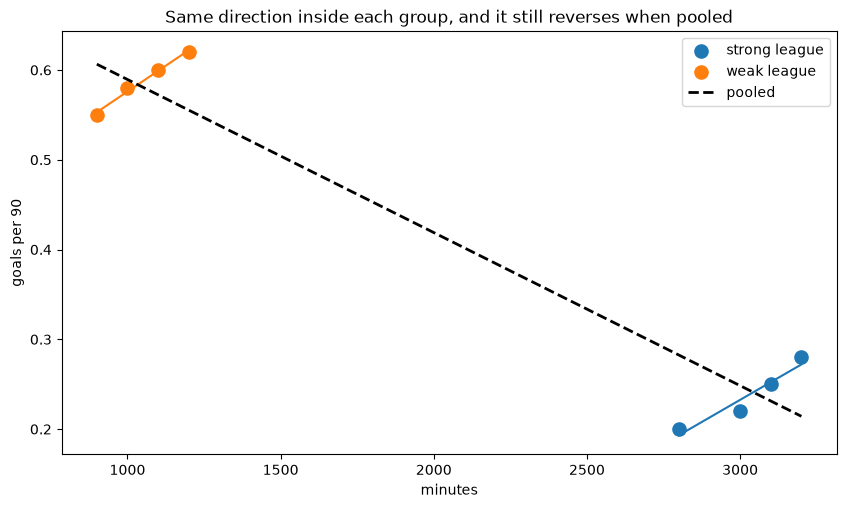

In [5]:
fig, ax = plt.subplots()
for name, group in paradox.groupby("league"):
    ax.scatter(group["minutes"], group["goals_p90"], s=90, label=f"{name} league")
    fit = np.polyfit(group["minutes"], group["goals_p90"], 1)
    xs = np.linspace(group["minutes"].min(), group["minutes"].max(), 10)
    ax.plot(xs, np.polyval(fit, xs), linewidth=1.5)

fit_all = np.polyfit(paradox["minutes"], paradox["goals_p90"], 1)
xs = np.linspace(paradox["minutes"].min(), paradox["minutes"].max(), 10)
ax.plot(xs, np.polyval(fit_all, xs), "k--", linewidth=2, label="pooled")
ax.set_xlabel("minutes")
ax.set_ylabel("goals per 90")
ax.set_title("Same direction inside each group, and it still reverses when pooled")
ax.legend()
plt.show()

Both league lines slope one way, and the pooled dashed line can get dragged
around by the difference *between* leagues rather than the relationship *within*
them. Which is exactly why this project z-scores inside `(league, season)`
before pooling anything, and why the "player is the unit, not the league"
decision is load-bearing rather than stylistic.

## 5. Assumptions

1. **Adaptation is the same in every direction.** $\alpha$ is one number. If
   moving to a harder league costs more adjustment than moving to an easier one,
   that asymmetry lands in the offsets instead.
2. **Age captures the career trajectory.** A linear age term is a crude stand-in
   for peak-and-decline.
3. **Selection is symmetric enough to cancel.** Players move up on good seasons
   and down on bad ones, and the hope is that these roughly offset. Hope is the
   right word for it.

## 6. How it breaks

**One-way traffic makes the parameters unidentifiable.** With moves in only one
direction between two leagues, adaptation and league strength are perfectly
collinear. Both apply to every move, and only their sign behaviour separates
them. The league-strength chapter shows the solver splitting the difference arbitrarily.

**And here is the failure that no amount of arithmetic fixes.** I only observe
players who were *selected to play*. Every conclusion in this book is
conditional on having played 900 minutes in a Big 5 league. The players who were
never given that chance are not in the denominator, and nothing here can say
anything at all about them.